# 33 - LSEG/Gemma original-33 universe robustness

**Question.** Do the frozen Notebook 30 capped exact-extrema rule and the
frozen Notebook 32 between-sector projection survive removal of all 11 later
breadth-addition companies?

This is an **immutable-universe robustness test on the already opened
2025-2026 window**, not a new time holdout. The original sector collection
contains the first three frozen members of each of 11 sectors; the fourth
member was added later solely to broaden the corpus. Both portfolio rules,
the one-session horizon, 25% input cap, 10 bps/side cost, ledger accounting,
inference, and gates are fixed before this replay. Nothing is fitted to
returns and no threshold, leverage, cap, breadth, or cost is swept.

The **primary universe-quality gate** applies Notebook 30's frozen rule and
requires at least 60 active sessions, net Sharpe >=0.75, maximum name weight
<=25%, break-even above 10 bps/side, and nonnegative net Sharpe in both
chronological halves. The secondary gate applies the same criteria to the
frozen Notebook 32 projection, with its three-member structural name bound of
16.67%. Each rule's **alpha gate** additionally requires its net-return
interval versus cash to exclude zero after BH correction across the two
predeclared rules. The paired rule comparison remains descriptive rather than
a selector.

A separate **sector-placement mechanism gate** repeats Notebook 32's 4,999
conditional random assignments using the original 33-company map. Cost
curves, attribution, and company/sector leave-one-out checks remain
diagnostics. The addition-only 11-company cohort gets a signal-only
feasibility count; its single-member sectors make the sector projection
undefined, so no add-11 return path is opened here.

In [1]:
from __future__ import annotations

import json
import math
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "final_experiments":
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from final_experiments.lib.aggregators import benjamini_hochberg  # noqa: E402
from final_experiments.lib.evaluate import annualized_sharpe  # noqa: E402
from final_experiments.lib.plots import CATEGORICAL, INK, apply_house_style  # noqa: E402
from final_experiments.lib.risk_overlay import (  # noqa: E402
    paired_block_bootstrap_difference,
)
from final_experiments.lib.sector_portfolios import (  # noqa: E402
    SECTOR_BY_SYMBOL,
    SECTOR_MEMBERS,
    validate_sector_map,
)
from final_experiments.lib.sparse_spread import (  # noqa: E402
    build_exact_extrema_targets,
    ledger_rows_to_frame,
    sector_project_targets,
)
from sentiment_benchmark.strategy_research.ledger import (  # noqa: E402
    run_open_to_open_ledger,
)
from sentiment_benchmark.strategy_research.market import OpenToOpenReturn  # noqa: E402

SEED = 20260808
COST_BPS = 10.0
COST_GRID = (0.0, 1.0, 2.0, 5.0, 10.0)
BLOCK_LENGTH = 5
REPLICATIONS = 4_999
GROSS_EXPOSURE = 1.0
BASE_SINGLE_NAME_CAP = 0.25
PROJECTED_NAME_BOUND = 1.0 / 6.0
MINIMUM_ACTIVE_SESSIONS = 60
INITIAL_NAV = 1_000_000.0
ARMS = ("capacity_capped", "between_sector")

GEMMA_PATH = (
    REPO_ROOT
    / "final_experiments/outputs/13_lseg_44_gemma_robustness"
    / "gemma4_26b_firm_open_aggregators.parquet"
)
NOTEBOOK30_MANIFEST = (
    REPO_ROOT
    / "final_experiments/outputs/30_lseg_gemma_capped_extrema_spread/manifest.json"
)
NOTEBOOK32_MANIFEST = (
    REPO_ROOT
    / "final_experiments/outputs/32_lseg_gemma_between_sector_extrema/manifest.json"
)
PRICE_PATHS = (
    REPO_ROOT / "Data/derived/prices/lseg_us_sector_33_8m.csv",
)
OUTPUT_DIR = REPO_ROOT / "final_experiments/outputs/33_lseg_gemma_original33_universe_robustness"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
apply_house_style()
pd.set_option("display.max_columns", 60)
pd.set_option("display.float_format", lambda value: f"{value:,.6f}")

## Frozen universe and exact return reproduction

Only aggregate firm-open signals and complete price opens are loaded. No
licensed headline text is displayed or persisted. Recomputed split-adjusted
open returns must exactly reproduce the Notebook 13 aggregate panel.

In [2]:
validate_sector_map()
original_sector_members = {
    sector: tuple(members[:3]) for sector, members in SECTOR_MEMBERS.items()
}
addition_symbols = tuple(members[3] for members in SECTOR_MEMBERS.values())
original_symbols = tuple(
    symbol for members in original_sector_members.values() for symbol in members
)
original_sector_by_symbol = {
    symbol: sector
    for sector, members in original_sector_members.items()
    for symbol in members
}
if len(original_symbols) != 33 or len(addition_symbols) != 11:
    raise RuntimeError("frozen 33+11 universe partition is malformed")
if set(original_symbols) & set(addition_symbols):
    raise RuntimeError("original and addition-only cohorts overlap")

gemma_full = pd.read_parquet(GEMMA_PATH)
gemma_full["session_date"] = pd.to_datetime(gemma_full["session_date"]).dt.normalize()
gemma_full["sector"] = gemma_full["symbol"].map(SECTOR_BY_SYMBOL)
gemma = gemma_full.loc[gemma_full["symbol"].isin(original_symbols)].copy()
addition_panel = gemma_full.loc[gemma_full["symbol"].isin(addition_symbols)].copy()
gemma["sector"] = gemma["symbol"].map(original_sector_by_symbol)
prices = pd.concat(
    [pd.read_csv(path, parse_dates=["session_date"]) for path in PRICE_PATHS],
    ignore_index=True,
)
prices["session_date"] = pd.to_datetime(prices["session_date"]).dt.normalize()
if gemma.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate Gemma firm-open rows")
if prices.duplicated(["session_date", "symbol"]).any():
    raise ValueError("duplicate price rows")
if gemma_full["sector"].isna().any() or gemma["sector"].isna().any():
    raise ValueError("Gemma symbols do not match the frozen sector map")

open_wide = prices.pivot(index="session_date", columns="symbol", values="open").sort_index().dropna()
sessions = pd.DatetimeIndex(sorted(gemma["session_date"].unique()))
symbols = tuple(sorted(gemma["symbol"].unique()))
if set(symbols) != set(original_symbols) or set(open_wide.columns) != set(original_symbols):
    raise ValueError("expected the immutable original 33-company population")
if not gemma.groupby("session_date")["symbol"].nunique().eq(33).all():
    raise ValueError("Gemma panel must contain all 33 original firms on every session")
locations = open_wide.index.get_indexer(sessions)
if (locations < 0).any() or not np.array_equal(locations[1:], locations[:-1] + 1):
    raise ValueError("Gemma sessions must be consecutive complete-price sessions")
if locations[-1] + 1 >= len(open_wide.index):
    raise ValueError("last signal session has no next complete open")

return_rows: list[OpenToOpenReturn] = []
recomputed_rows: list[dict[str, object]] = []
for session, location in zip(sessions, locations, strict=True):
    next_session = open_wide.index[location + 1]
    values = open_wide.loc[next_session, list(symbols)] / open_wide.loc[session, list(symbols)] - 1.0
    for symbol, value in values.items():
        return_rows.append(
            OpenToOpenReturn(
                symbol=symbol,
                session=str(session.date()),
                next_session=str(next_session.date()),
                value=float(value),
            )
        )
        recomputed_rows.append(
            {"session_date": session, "symbol": symbol, "recomputed_raw_open_h1": float(value)}
        )
return_audit = gemma[["session_date", "symbol", "raw_open_h1"]].merge(
    pd.DataFrame(recomputed_rows),
    on=["session_date", "symbol"],
    how="left",
    validate="1:1",
)
return_audit["absolute_error"] = (
    return_audit["raw_open_h1"] - return_audit["recomputed_raw_open_h1"]
).abs()
if return_audit["absolute_error"].max() > 1e-12:
    raise RuntimeError("price-derived returns do not reproduce Notebook 13")
coverage = pd.DataFrame(
    [
        {
            "firm_open_rows": len(gemma),
            "sessions": len(sessions),
            "companies": len(symbols),
            "sectors": gemma["sector"].nunique(),
            "members_per_sector": 3,
            "excluded_breadth_additions": len(addition_symbols),
            "first_entry_session": sessions.min(),
            "last_entry_session": sessions.max(),
            "last_return_end": open_wide.index[locations[-1] + 1],
            "max_return_reproduction_error": float(return_audit["absolute_error"].max()),
        }
    ]
)
display(coverage)

# Signal-only feasibility for the fourth company in each sector. Returns are
# deliberately not loaded for this diagnostic.
addition_targets, addition_audit = build_exact_extrema_targets(
    addition_panel,
    gross_exposure=GROSS_EXPOSURE,
    minimum_names_per_side=1,
    single_name_cap=BASE_SINGLE_NAME_CAP,
)
addition_feasibility = pd.DataFrame(
    [
        {
            "companies": len(addition_symbols),
            "sessions": addition_audit["session_date"].nunique(),
            "active_sessions": int(addition_audit["eligible"].sum()),
            "minimum_active_sessions": MINIMUM_ACTIVE_SESSIONS,
            "capped_stock_rule_feasible": bool(
                addition_audit["eligible"].sum() >= MINIMUM_ACTIVE_SESSIONS
            ),
            "sector_projection_feasible": False,
            "reason": "one breadth-addition company per sector",
            "return_data_loaded": False,
        }
    ]
)
display(addition_feasibility)

,firm_open_rows,sessions,companies,sectors,members_per_sector,excluded_breadth_additions,first_entry_session,last_entry_session,last_return_end,max_return_reproduction_error
0,5511,167,33,11,3,11,2025-10-27,2026-06-26,2026-06-29,0.000000


,companies,sessions,active_sessions,minimum_active_sessions,capped_stock_rule_feasible,sector_projection_feasible,reason,return_data_loaded
0,11,167,3,60,False,False,one breadth-addition company per sector,False


## Frozen original-33 constructions

The projection is computed from capped targets before any return is used.
Jensen's inequality implies that equal-weight sector projection cannot have
more gross exposure than its input; the notebook also verifies the tighter
16.67% structural name bound and exact dollar neutrality.

In [3]:
capped_targets, capped_audit = build_exact_extrema_targets(
    gemma,
    gross_exposure=GROSS_EXPOSURE,
    minimum_names_per_side=1,
    single_name_cap=BASE_SINGLE_NAME_CAP,
)
projected_targets, projected_audit = sector_project_targets(
    capped_targets,
    sector_by_symbol=original_sector_by_symbol,
    gross_exposure=GROSS_EXPOSURE,
    single_name_cap=BASE_SINGLE_NAME_CAP,
)
if (projected_audit["projected_gross_exposure"] - projected_audit["base_gross_exposure"] > 1e-12).any():
    raise RuntimeError("sector projection increased gross exposure")
if projected_audit["projected_max_name_weight"].max() > PROJECTED_NAME_BOUND + 1e-12:
    raise RuntimeError("sector projection exceeded the frozen structural name bound")
if max(abs(target.net_exposure) for target in projected_targets) > 1e-12:
    raise RuntimeError("projected targets are not dollar-neutral")
if projected_audit["scale_multiplier"].lt(1.0 - 1e-12).any():
    raise RuntimeError("valid capped inputs unexpectedly required projection scaling")

projected_active = projected_audit["projected_gross_exposure"].gt(0)
construction_audit = pd.DataFrame(
    [
        {
            "sessions": len(capped_audit),
            "capped_active_sessions": int(capped_audit["eligible"].sum()),
            "projected_active_sessions": int(projected_active.sum()),
            "sessions_removed_as_pure_within_sector_opposition": int(
                (capped_audit["eligible"] & ~projected_active).sum()
            ),
            "capped_mean_gross_exposure": float(capped_audit["gross_exposure"].mean()),
            "projected_mean_gross_exposure": float(
                projected_audit["projected_gross_exposure"].mean()
            ),
            "projected_mean_active_gross_exposure": float(
                projected_audit.loc[projected_active, "projected_gross_exposure"].mean()
            ),
            "capped_max_name_weight": float(capped_audit["max_abs_name_weight"].max()),
            "projected_max_name_weight": float(
                projected_audit["projected_max_name_weight"].max()
            ),
            "mean_active_sectors": float(
                projected_audit.loc[projected_active, "active_sectors"].mean()
            ),
            "mean_projected_names": float(
                projected_audit.loc[projected_active, "projected_names"].mean()
            ),
            "mean_non_signal_peers": float(
                projected_audit.loc[projected_active, "non_signal_peer_names"].mean()
            ),
        }
    ]
)
display(construction_audit.T)

,0
sessions,167.000000
capped_active_sessions,70.000000
projected_active_sessions,68.000000
sessions_removed_as_pure_within_sector_opposition,2.000000
capped_mean_gross_exposure,0.248503
projected_mean_gross_exposure,0.234681
projected_mean_active_gross_exposure,0.576348
capped_max_name_weight,0.250000
projected_max_name_weight,0.166667
mean_active_sectors,2.985294


## Drift-aware ledger and frozen 44-company references

In [4]:
def fold_final_liquidation(frame: pd.DataFrame) -> pd.DataFrame:
    liquidation = frame.loc[frame["final_liquidation"]]
    intervals = frame.loc[~frame["final_liquidation"]].copy().reset_index(drop=True)
    if len(liquidation) != 1 or intervals.empty:
        raise RuntimeError("expected one final liquidation after non-empty intervals")
    final = liquidation.iloc[0]
    last = intervals.index[-1]
    intervals.loc[last, "net_return"] = (
        (1.0 + intervals.loc[last, "net_return"]) * (1.0 + final["net_return"]) - 1.0
    )
    intervals.loc[last, "turnover"] += final["turnover"]
    intervals.loc[last, "cost"] += final["cost"]
    intervals.loc[last, "end_nav"] = final["end_nav"]
    intervals["downside_sq"] = np.minimum(intervals["net_return"], 0.0) ** 2
    return intervals


def run_targets(
    target_rows: tuple,
    return_values: list[OpenToOpenReturn],
    *,
    cost_bps: float,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    ledger = run_open_to_open_ledger(
        target_rows,
        return_values,
        cost_rate_per_side=cost_bps / 10_000.0,
        initial_nav_usd=INITIAL_NAV,
        force_final_liquidation=True,
    )
    full = ledger_rows_to_frame(ledger)
    return fold_final_liquidation(full), full


def summarize_path(daily: pd.DataFrame, *, cost_bps: float) -> dict[str, float | int]:
    gross = daily["gross_return"].to_numpy(dtype=float)
    net = daily["net_return"].to_numpy(dtype=float)
    gross_equity = np.cumprod(1.0 + gross)
    net_equity = np.cumprod(1.0 + net)
    with_start = np.r_[1.0, net_equity]
    peaks = np.maximum.accumulate(with_start)
    turnover_sum = float(daily["turnover"].sum())
    return {
        "n_sessions": int(len(daily)),
        "active_sessions": int(daily["gross_exposure"].gt(0).sum()),
        "mean_gross": float(np.mean(gross)),
        "mean_net": float(np.mean(net)),
        "sharpe_gross": annualized_sharpe(pd.Series(gross)),
        "sharpe_net": annualized_sharpe(pd.Series(net)),
        "ann_vol_net": float(np.std(net, ddof=1) * math.sqrt(252)),
        "total_return_gross": float(gross_equity[-1] - 1.0),
        "total_return_net": float(net_equity[-1] - 1.0),
        "max_drawdown": float(np.min(with_start / peaks - 1.0)),
        "mean_turnover": float(turnover_sum / len(daily)),
        "total_turnover": turnover_sum,
        "mean_gross_exposure": float(daily["gross_exposure"].mean()),
        "mean_active_names": float(daily.loc[daily["gross_exposure"].gt(0), "active_names"].mean()),
        "max_abs_net_exposure": float(daily["net_exposure"].abs().max()),
        "breakeven_bps_per_side": float(10_000.0 * gross.sum() / turnover_sum),
        "cost_bps_per_side": cost_bps,
    }


target_paths = {
    "capacity_capped": capped_targets,
    "between_sector": projected_targets,
}
daily_paths: dict[str, pd.DataFrame] = {}
ledger_paths: dict[str, pd.DataFrame] = {}
for arm in ARMS:
    daily_paths[arm], ledger_paths[arm] = run_targets(
        target_paths[arm], return_rows, cost_bps=COST_BPS
    )
results = pd.DataFrame(
    [
        {
            "universe": "original33",
            "arm": arm,
            **summarize_path(daily_paths[arm], cost_bps=COST_BPS),
        }
        for arm in ARMS
    ]
)

notebook30 = json.loads(NOTEBOOK30_MANIFEST.read_text())
notebook32 = json.loads(NOTEBOOK32_MANIFEST.read_text())
reference44 = {
    "capacity_capped": pd.DataFrame(notebook30["results"])
    .set_index("arm")
    .loc["capacity_capped"],
    "between_sector": pd.DataFrame(notebook32["results"])
    .set_index("arm")
    .loc["between_sector"],
}
comparison_metrics = (
    "active_sessions",
    "sharpe_gross",
    "sharpe_net",
    "total_return_net",
    "max_drawdown",
    "mean_turnover",
    "breakeven_bps_per_side",
)
universe_comparison_rows = []
for arm in ARMS:
    original = results.set_index("arm").loc[arm]
    reference = reference44[arm]
    for metric in comparison_metrics:
        original_value = float(original[metric])
        reference_value = float(reference[metric])
        universe_comparison_rows.append(
            {
                "arm": arm,
                "metric": metric,
                "original33": original_value,
                "expanded44": reference_value,
                "original33_minus_expanded44": original_value - reference_value,
            }
        )
universe_comparison = pd.DataFrame(universe_comparison_rows)
display(results.T)
display(universe_comparison)

,0,1
universe,original33,original33
arm,capacity_capped,between_sector
n_sessions,167,167
active_sessions,70,68
mean_gross,0.000998,0.000824
mean_net,0.000605,0.000470
sharpe_gross,3.343571,4.182970
sharpe_net,2.046340,2.421115
ann_vol_net,0.074485,0.048872
total_return_gross,0.179155,0.146520


,arm,metric,original33,expanded44,original33_minus_expanded44
0,capacity_capped,active_sessions,70.000000,80.000000,-10.000000
1,capacity_capped,sharpe_gross,3.343571,2.945235,0.398335
2,capacity_capped,sharpe_net,2.046340,1.696870,0.349470
3,capacity_capped,total_return_net,0.104240,0.102037,0.002202
4,capacity_capped,max_drawdown,-0.034238,-0.049705,0.015467
5,capacity_capped,mean_turnover,0.393587,0.451303,-0.057717
6,capacity_capped,breakeven_bps_per_side,25.367665,23.237764,2.129901
7,between_sector,active_sessions,68.000000,78.000000,-10.000000
8,between_sector,sharpe_gross,4.182970,3.805442,0.377528
9,between_sector,sharpe_net,2.421115,1.868256,0.552859


## Paired policy inference and conditional sector-placement randomisation

Positive paired estimates favour the sector projection. Downside is coded as
capped minus projected so lower projected loss is positive. The conditional
random-label null preserves each session's positive/negative counts and the
exact sector-projection rule; only firm assignment changes.

In [5]:
inference_rows = []
for outcome_offset, outcome in enumerate(("net_return", "downside_sq")):
    if outcome == "net_return":
        challenger = daily_paths["between_sector"]
        baseline = daily_paths["capacity_capped"]
    else:
        challenger = daily_paths["capacity_capped"]
        baseline = daily_paths["between_sector"]
    estimate = paired_block_bootstrap_difference(
        challenger,
        baseline,
        value_col=outcome,
        block_length=BLOCK_LENGTH,
        replications=REPLICATIONS,
        seed=SEED + outcome_offset,
    )
    inference_rows.append(
        {"outcome": outcome, "positive_favours_between_sector": True, **estimate}
    )
paired_inference = pd.DataFrame(inference_rows)
paired_inference["bh_reject_q05"] = benjamini_hochberg(
    paired_inference["p_two_sided"].tolist(), q=0.05
)
cash = daily_paths["between_sector"][["session_date"]].copy()
cash["net_return"] = 0.0
rule_vs_cash = pd.DataFrame(
    [
        {
            "arm": arm,
            "comparison": f"{arm}_minus_cash",
            **paired_block_bootstrap_difference(
                daily_paths[arm],
                cash,
                value_col="net_return",
                block_length=BLOCK_LENGTH,
                replications=REPLICATIONS,
                seed=SEED + 10 + arm_number,
            ),
        }
        for arm_number, arm in enumerate(ARMS)
    ]
)
rule_vs_cash["bh_reject_q05"] = benjamini_hochberg(
    rule_vs_cash["p_two_sided"].tolist(), q=0.05
)

return_matrix = np.vstack(
    [
        (
            open_wide.loc[open_wide.index[location + 1], list(symbols)]
            / open_wide.loc[session, list(symbols)]
            - 1.0
        ).to_numpy(dtype=float)
        for session, location in zip(sessions, locations, strict=True)
    ]
)


def target_matrix(target_rows: tuple, ordered_symbols: tuple[str, ...]) -> np.ndarray:
    return np.vstack(
        [
            np.array([target.weights()[symbol] for symbol in ordered_symbols], dtype=float)
            for target in target_rows
        ]
    )


projected_weights = target_matrix(projected_targets, symbols)
actual_session_gross = np.sum(projected_weights * return_matrix, axis=1)
if not np.allclose(actual_session_gross, daily_paths["between_sector"]["gross_return"], atol=1e-14):
    raise RuntimeError("projected target weights do not reproduce ledger gross returns")

symbol_index = {symbol: index for index, symbol in enumerate(symbols)}
sector_indices = [
    np.array([symbol_index[symbol] for symbol in members], dtype=int)
    for members in original_sector_members.values()
]
counts = capped_audit[["positive_names", "negative_names", "eligible"]].to_dict("records")
rng = np.random.default_rng(SEED + 20)
random_means = np.zeros(REPLICATIONS, dtype=float)
for replication in range(REPLICATIONS):
    total = 0.0
    for row_number, count in enumerate(counts):
        if not count["eligible"]:
            continue
        n_positive = int(count["positive_names"])
        n_negative = int(count["negative_names"])
        leg = min(
            0.5,
            BASE_SINGLE_NAME_CAP * n_positive,
            BASE_SINGLE_NAME_CAP * n_negative,
        )
        order = rng.permutation(len(symbols))
        weights = np.zeros(len(symbols), dtype=float)
        weights[order[:n_positive]] = leg / n_positive
        weights[order[n_positive : n_positive + n_negative]] = -leg / n_negative
        for indices in sector_indices:
            weights[indices] = float(weights[indices].mean())
        total += float(weights @ return_matrix[row_number])
    random_means[replication] = total / len(sessions)

actual_gross_mean = float(actual_session_gross.mean())
randomisation = pd.DataFrame(
    [
        {
            "replications": REPLICATIONS,
            "seed": SEED + 20,
            "actual_gross_mean": actual_gross_mean,
            "null_mean": float(random_means.mean()),
            "null_ci_low": float(np.quantile(random_means, 0.025)),
            "null_ci_high": float(np.quantile(random_means, 0.975)),
            "p_one_sided_actual_ge_null": float(
                (1 + np.sum(random_means >= actual_gross_mean)) / (REPLICATIONS + 1)
            ),
            "p_two_sided": float(
                (1 + np.sum(np.abs(random_means) >= abs(actual_gross_mean)))
                / (REPLICATIONS + 1)
            ),
        }
    ]
)
display(paired_inference)
display(rule_vs_cash)
display(randomisation)

,outcome,positive_favours_between_sector,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,bh_reject_q05
0,net_return,True,167,-0.000135,-0.000577,0.000348,0.571000,5,4999,20260808,False
1,downside_sq,True,167,0.000005,0.000001,0.000010,0.036200,5,4999,20260809,False


,arm,comparison,n_sessions,mean_difference,ci_low,ci_high,p_two_sided,block_length,replications,seed,bh_reject_q05
0,capacity_capped,capacity_capped_minus_cash,167,0.000605,-0.000049,0.001242,0.067000,5,4999,20260818,False
1,between_sector,between_sector_minus_cash,167,0.000470,0.000018,0.000885,0.034600,5,4999,20260819,False


,replications,seed,actual_gross_mean,null_mean,null_ci_low,null_ci_high,p_one_sided_actual_ge_null,p_two_sided
0,4999,20260828,0.000824,-0.000005,-0.000482,0.000491,0.001000,0.001400


## Costs and chronological stability

In [6]:
cost_rows = []
for cost in COST_GRID:
    for arm in ARMS:
        daily, _ = run_targets(target_paths[arm], return_rows, cost_bps=cost)
        cost_rows.append({"arm": arm, **summarize_path(daily, cost_bps=cost)})
cost_curve = pd.DataFrame(cost_rows)

midpoint = len(sessions) // 2
half_indices = {"first_half": sessions[:midpoint], "second_half": sessions[midpoint:]}
temporal_rows = []
for period, index in half_indices.items():
    half_panel = gemma.loc[gemma["session_date"].isin(index)].copy()
    half_return_sessions = {str(session.date()) for session in index}
    half_returns = [row for row in return_rows if row.session in half_return_sessions]
    half_capped = build_exact_extrema_targets(
        half_panel, single_name_cap=BASE_SINGLE_NAME_CAP
    )[0]
    half_targets = {
        "capacity_capped": half_capped,
        "between_sector": sector_project_targets(
            half_capped,
            sector_by_symbol=original_sector_by_symbol,
            single_name_cap=BASE_SINGLE_NAME_CAP,
        )[0],
    }
    for arm in ARMS:
        daily, _ = run_targets(half_targets[arm], half_returns, cost_bps=COST_BPS)
        temporal_rows.append(
            {"period": period, "arm": arm, **summarize_path(daily, cost_bps=COST_BPS)}
        )
temporal = pd.DataFrame(temporal_rows)
display(cost_curve)
display(temporal)

,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,mean_active_names,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,capacity_capped,167,70,0.000998,0.000998,3.343571,3.343571,0.075251,0.179155,0.179155,-0.029020,0.393445,65.705369,0.248503,3.214286,0.000000,25.376777,0.000000
1,between_sector,167,68,0.000824,0.000824,4.182970,4.182970,0.049637,0.146520,0.146520,-0.018664,0.354270,59.163172,0.234681,8.955882,0.000000,23.257117,0.000000
2,capacity_capped,167,70,0.000998,0.000959,3.343571,3.215936,0.075154,0.179155,0.171445,-0.029543,0.393459,65.707711,0.248503,3.214286,0.000000,25.375873,1.000000
3,between_sector,167,68,0.000824,0.000789,4.182970,4.011492,0.049533,0.146520,0.139766,-0.019373,0.354282,59.165172,0.234681,8.955882,0.000000,23.256330,1.000000
4,capacity_capped,167,70,0.000998,0.000920,3.343571,3.087782,0.075062,0.179155,0.163785,-0.030065,0.393473,65.710053,0.248503,3.214286,0.000000,25.374968,2.000000
5,between_sector,167,68,0.000824,0.000753,4.182970,3.838820,0.049436,0.146520,0.133050,-0.020180,0.354294,59.167173,0.234681,8.955882,0.000000,23.255544,2.000000
6,capacity_capped,167,70,0.000998,0.000802,3.343571,2.700406,0.074812,0.179155,0.141096,-0.031632,0.393515,65.717083,0.248503,3.214286,0.000000,25.372254,5.000000
7,between_sector,167,68,0.000824,0.000647,4.182970,3.314167,0.049178,0.146520,0.113135,-0.022598,0.354330,59.173179,0.234681,8.955882,0.000000,23.253183,5.000000
8,capacity_capped,167,70,0.000998,0.000605,3.343571,2.046340,0.074485,0.179155,0.104240,-0.034238,0.393587,65.728971,0.248503,3.214286,0.000000,25.367665,10.000000
9,between_sector,167,68,0.000824,0.000470,4.182970,2.421115,0.048872,0.146520,0.080701,-0.026617,0.354390,59.183196,0.234681,8.955882,0.000000,23.249248,10.000000


,period,arm,n_sessions,active_sessions,mean_gross,mean_net,sharpe_gross,sharpe_net,ann_vol_net,total_return_gross,total_return_net,max_drawdown,mean_turnover,total_turnover,mean_gross_exposure,mean_active_names,max_abs_net_exposure,breakeven_bps_per_side,cost_bps_per_side
0,first_half,capacity_capped,83,21,0.000479,0.000192,1.601496,0.648584,0.074618,0.039591,0.015145,-0.034238,0.287003,23.821211,0.150602,3.000000,0.000000,16.691461,10.000000
1,first_half,between_sector,83,19,0.000347,0.000094,1.986695,0.542854,0.043593,0.028908,0.007513,-0.026617,0.253305,21.024352,0.135040,8.842105,0.000000,13.707300,10.000000
2,second_half,capacity_capped,84,49,0.001512,0.001013,5.101135,3.438116,0.074230,0.134249,0.087765,-0.014005,0.498902,41.907760,0.345238,3.306122,0.000000,30.299393,10.000000
3,second_half,between_sector,84,49,0.001295,0.000841,6.062455,3.983331,0.053186,0.114307,0.072643,-0.010161,0.454272,38.158844,0.333135,9.000000,0.000000,28.506568,10.000000


## Factor exposure, attribution, and dependence diagnostics

In [7]:
weight_paths = {
    "capacity_capped": target_matrix(capped_targets, symbols),
    "between_sector": projected_weights,
}
equal_weight_market = return_matrix.mean(axis=1)
factor_rows = []
company_attribution = pd.DataFrame(
    {
        "symbol": symbols,
        "sector": [original_sector_by_symbol[symbol] for symbol in symbols],
    }
)
for arm in ARMS:
    weights = weight_paths[arm]
    gross_return = np.sum(weights * return_matrix, axis=1)
    factor_rows.append(
        {
            "arm": arm,
            "equal_weight_market_beta": float(
                np.cov(gross_return, equal_weight_market, ddof=1)[0, 1]
                / np.var(equal_weight_market, ddof=1)
            ),
            "equal_weight_market_correlation": float(
                np.corrcoef(gross_return, equal_weight_market)[0, 1]
            ),
        }
    )
    contribution = weights * return_matrix
    company_attribution[f"{arm}_gross_contribution"] = contribution.sum(axis=0)
    company_attribution[f"{arm}_active_sessions"] = (np.abs(weights) > 1e-12).sum(axis=0)
factor_exposure = pd.DataFrame(factor_rows)
sector_attribution = (
    company_attribution.groupby("sector", as_index=False)
    .agg(
        capped_gross_contribution=("capacity_capped_gross_contribution", "sum"),
        projected_gross_contribution=("between_sector_gross_contribution", "sum"),
        projected_member_sessions=("between_sector_active_sessions", "sum"),
    )
    .sort_values("projected_gross_contribution", ascending=False, ignore_index=True)
)
total_absolute_sector_contribution = float(
    sector_attribution["projected_gross_contribution"].abs().sum()
)
sector_attribution["projected_absolute_contribution_share"] = (
    sector_attribution["projected_gross_contribution"].abs()
    / total_absolute_sector_contribution
)

leave_one_company_rows = []
for removed_symbol in symbols:
    remaining = [symbol for symbol in symbols if symbol != removed_symbol]
    reduced_panel = gemma.loc[gemma["symbol"].isin(remaining)].copy()
    reduced_capped, reduced_capped_audit = build_exact_extrema_targets(
        reduced_panel, single_name_cap=BASE_SINGLE_NAME_CAP
    )
    reduced_projected = sector_project_targets(
        reduced_capped,
        sector_by_symbol={
            symbol: original_sector_by_symbol[symbol] for symbol in remaining
        },
        single_name_cap=BASE_SINGLE_NAME_CAP,
    )[0]
    reduced_returns = [row for row in return_rows if row.symbol in remaining]
    reduced_daily, _ = run_targets(reduced_projected, reduced_returns, cost_bps=COST_BPS)
    leave_one_company_rows.append(
        {
            "removed_symbol": removed_symbol,
            "eligible_sessions": int(reduced_capped_audit["eligible"].sum()),
            **summarize_path(reduced_daily, cost_bps=COST_BPS),
        }
    )
leave_one_company = pd.DataFrame(leave_one_company_rows).sort_values(
    "sharpe_net", ascending=True, ignore_index=True
)

leave_one_sector_rows = []
for removed_sector, removed_symbols in original_sector_members.items():
    remaining = [symbol for symbol in symbols if symbol not in removed_symbols]
    reduced_panel = gemma.loc[gemma["symbol"].isin(remaining)].copy()
    reduced_capped, reduced_capped_audit = build_exact_extrema_targets(
        reduced_panel, single_name_cap=BASE_SINGLE_NAME_CAP
    )
    reduced_projected = sector_project_targets(
        reduced_capped,
        sector_by_symbol={
            symbol: original_sector_by_symbol[symbol] for symbol in remaining
        },
        single_name_cap=BASE_SINGLE_NAME_CAP,
    )[0]
    reduced_returns = [row for row in return_rows if row.symbol in remaining]
    reduced_daily, _ = run_targets(reduced_projected, reduced_returns, cost_bps=COST_BPS)
    leave_one_sector_rows.append(
        {
            "removed_sector": removed_sector,
            "eligible_sessions": int(reduced_capped_audit["eligible"].sum()),
            **summarize_path(reduced_daily, cost_bps=COST_BPS),
        }
    )
leave_one_sector = pd.DataFrame(leave_one_sector_rows).sort_values(
    "sharpe_net", ascending=True, ignore_index=True
)
dependence_summary = pd.DataFrame(
    [
        {
            "leave_one_company_replays": len(leave_one_company),
            "positive_company_replays": int(
                leave_one_company["total_return_net"].gt(0).sum()
            ),
            "minimum_company_loo_sharpe": float(leave_one_company["sharpe_net"].min()),
            "median_company_loo_sharpe": float(leave_one_company["sharpe_net"].median()),
            "leave_one_sector_replays": len(leave_one_sector),
            "positive_sector_replays": int(leave_one_sector["total_return_net"].gt(0).sum()),
            "minimum_sector_loo_sharpe": float(leave_one_sector["sharpe_net"].min()),
            "largest_sector_absolute_share": float(
                sector_attribution["projected_absolute_contribution_share"].max()
            ),
            "largest_sector": str(sector_attribution.iloc[0]["sector"]),
        }
    ]
)
display(factor_exposure)
display(sector_attribution)
display(dependence_summary.T)

,arm,equal_weight_market_beta,equal_weight_market_correlation
0,capacity_capped,0.110062,0.164748
1,between_sector,0.078330,0.177752


,sector,capped_gross_contribution,projected_gross_contribution,projected_member_sessions,projected_absolute_contribution_share
0,financials,0.079173,0.052082,162,0.357925
1,communication_services,0.006958,0.035525,144,0.244143
2,healthcare,0.019079,0.016402,72,0.112722
3,consumer_discretionary,0.014636,0.010930,72,0.075117
4,energy,0.007298,0.010044,18,0.069024
5,consumer_staples,0.015017,0.007671,27,0.052716
6,materials,0.014484,0.006168,15,0.042392
7,real_estate,-0.001118,0.002731,3,0.018766
8,utilities,0.000000,0.000000,0,0.000000
9,information_technology,0.016394,-0.000911,81,0.006261


,0
leave_one_company_replays,33
positive_company_replays,33
minimum_company_loo_sharpe,1.565716
median_company_loo_sharpe,2.400742
leave_one_sector_replays,11
positive_sector_replays,11
minimum_sector_loo_sharpe,1.420674
largest_sector_absolute_share,0.357925
largest_sector,financials


## Frozen gates

In [8]:
result_index = results.set_index("arm")
capped = result_index.loc["capacity_capped"]
projected = result_index.loc["between_sector"]
paired_index = paired_inference.set_index("outcome")
paired_return = paired_index.loc["net_return"]
cash_index = rule_vs_cash.set_index("arm")
random_row = randomisation.iloc[0]
temporal_index = temporal.set_index(["period", "arm"])
half_sharpes = {
    arm: {
        period: float(temporal_index.loc[(period, arm), "sharpe_net"])
        for period in half_indices
    }
    for arm in ARMS
}
sector_placement_mechanism_gate = bool(
    random_row["actual_gross_mean"] > random_row["null_mean"]
    and random_row["p_one_sided_actual_ge_null"] < 0.05
)
primary_universe_quality_gate = bool(
    capped["active_sessions"] >= MINIMUM_ACTIVE_SESSIONS
    and capped["sharpe_net"] >= 0.75
    and construction_audit.loc[0, "capped_max_name_weight"]
    <= BASE_SINGLE_NAME_CAP + 1e-12
    and capped["breakeven_bps_per_side"] > COST_BPS
    and all(value >= 0 for value in half_sharpes["capacity_capped"].values())
)
secondary_universe_quality_gate = bool(
    projected["active_sessions"] >= MINIMUM_ACTIVE_SESSIONS
    and projected["sharpe_net"] >= 0.75
    and construction_audit.loc[0, "projected_max_name_weight"] <= PROJECTED_NAME_BOUND + 1e-12
    and projected["breakeven_bps_per_side"] > COST_BPS
    and all(value >= 0 for value in half_sharpes["between_sector"].values())
)
primary_alpha_gate = bool(
    cash_index.loc["capacity_capped", "ci_low"] > 0
    and cash_index.loc["capacity_capped", "bh_reject_q05"]
    and capped["mean_net"] > 0
)
secondary_alpha_gate = bool(
    cash_index.loc["between_sector", "ci_low"] > 0
    and cash_index.loc["between_sector", "bh_reject_q05"]
    and projected["mean_net"] > 0
)
gates = pd.DataFrame(
    [
        {
            "sector_placement_mechanism_gate": sector_placement_mechanism_gate,
            "primary_universe_quality_gate": primary_universe_quality_gate,
            "secondary_universe_quality_gate": secondary_universe_quality_gate,
            "primary_alpha_gate": primary_alpha_gate,
            "secondary_alpha_gate": secondary_alpha_gate,
            "projected_minus_capped_sharpe": float(projected["sharpe_net"] - capped["sharpe_net"]),
            "projected_minus_capped_bps_session": float(paired_return["mean_difference"] * 10_000),
            "paired_ci_low_bps_session": float(paired_return["ci_low"] * 10_000),
            "paired_ci_high_bps_session": float(paired_return["ci_high"] * 10_000),
            "paired_p_two_sided": float(paired_return["p_two_sided"]),
            "paired_return_bh_reject": bool(paired_return["bh_reject_q05"]),
            "randomisation_p_one_sided": float(random_row["p_one_sided_actual_ge_null"]),
            "capped_vs_cash_ci_low_bps_session": float(
                cash_index.loc["capacity_capped", "ci_low"] * 10_000
            ),
            "capped_vs_cash_p_two_sided": float(
                cash_index.loc["capacity_capped", "p_two_sided"]
            ),
            "projected_vs_cash_ci_low_bps_session": float(
                cash_index.loc["between_sector", "ci_low"] * 10_000
            ),
            "projected_vs_cash_p_two_sided": float(
                cash_index.loc["between_sector", "p_two_sided"]
            ),
            "capped_breakeven_bps_per_side": float(capped["breakeven_bps_per_side"]),
            "projected_breakeven_bps_per_side": float(projected["breakeven_bps_per_side"]),
            "first_half_capped_net_sharpe": half_sharpes["capacity_capped"]["first_half"],
            "second_half_capped_net_sharpe": half_sharpes["capacity_capped"]["second_half"],
            "first_half_projected_net_sharpe": half_sharpes["between_sector"]["first_half"],
            "second_half_projected_net_sharpe": half_sharpes["between_sector"]["second_half"],
            "projected_max_name_weight": float(
                construction_audit.loc[0, "projected_max_name_weight"]
            ),
        }
    ]
)
display(gates.T)

,0
sector_placement_mechanism_gate,True
primary_universe_quality_gate,True
secondary_universe_quality_gate,True
primary_alpha_gate,False
secondary_alpha_gate,False
projected_minus_capped_sharpe,0.374775
projected_minus_capped_bps_session,-1.353102
paired_ci_low_bps_session,-5.767979
paired_ci_high_bps_session,3.477039
paired_p_two_sided,0.571000


## Figures

findfont: Failed to find font weight medium, now using 400.


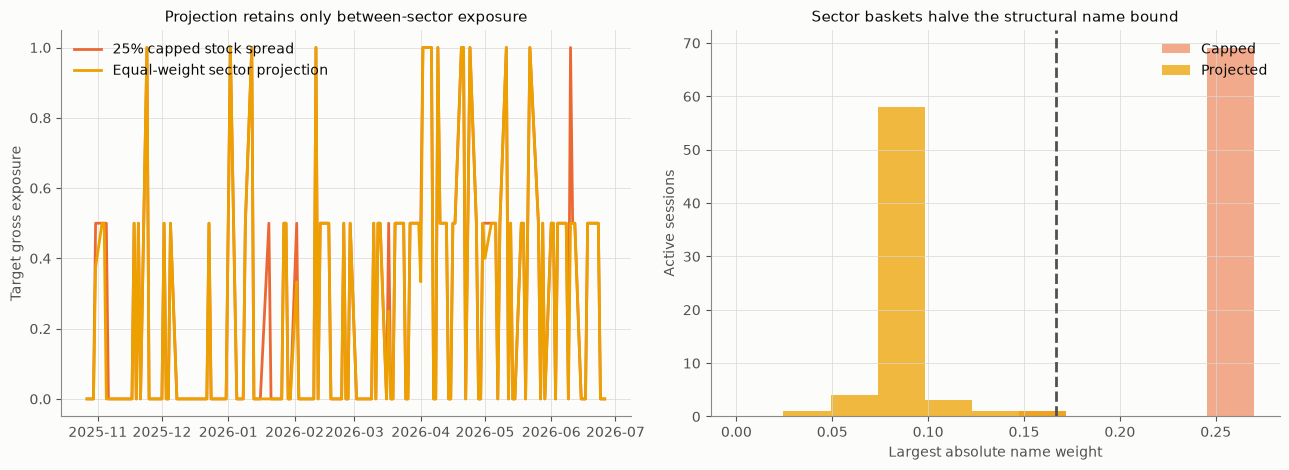

In [9]:
labels = {
    "capacity_capped": "25% capped stock spread",
    "between_sector": "Equal-weight sector projection",
}
colours = {"capacity_capped": CATEGORICAL[1], "between_sector": CATEGORICAL[3]}
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].plot(
    capped_audit["session_date"],
    capped_audit["gross_exposure"],
    color=colours["capacity_capped"],
    label=labels["capacity_capped"],
)
axes[0].plot(
    projected_audit["session_date"],
    projected_audit["projected_gross_exposure"],
    color=colours["between_sector"],
    label=labels["between_sector"],
)
axes[0].set_ylabel("Target gross exposure")
axes[0].set_title("Projection retains only between-sector exposure")
axes[0].legend(loc="upper left")
active_capped = capped_audit.loc[capped_audit["eligible"], "max_abs_name_weight"]
active_projected = projected_audit.loc[projected_active, "projected_max_name_weight"]
bins = np.linspace(0.0, 0.27, 12)
axes[1].hist(
    active_capped, bins=bins, alpha=0.55, color=colours["capacity_capped"], label="Capped"
)
axes[1].hist(
    active_projected, bins=bins, alpha=0.75, color=colours["between_sector"], label="Projected"
)
axes[1].axvline(PROJECTED_NAME_BOUND, color=INK["reference"], linestyle="--")
axes[1].set_xlabel("Largest absolute name weight")
axes[1].set_ylabel("Active sessions")
axes[1].set_title("Sector baskets halve the structural name bound")
axes[1].legend(loc="upper right")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "construction_and_concentration.png", dpi=170, bbox_inches="tight")
plt.show()

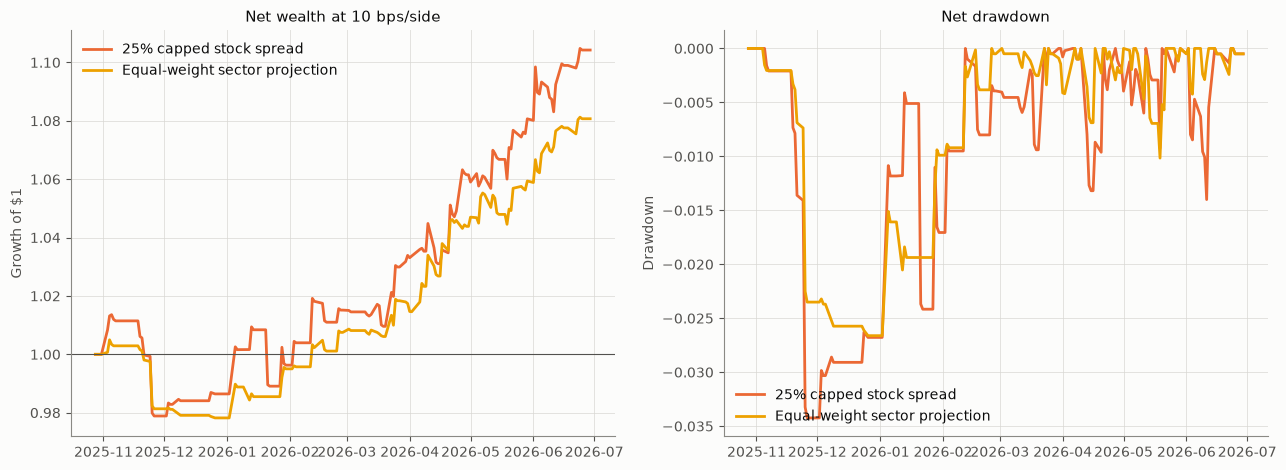

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for arm in ARMS:
    daily = daily_paths[arm]
    equity = (1.0 + daily["net_return"]).cumprod()
    drawdown = equity / np.maximum.accumulate(np.r_[1.0, equity])[1:] - 1.0
    axes[0].plot(daily["return_end_date"], equity, color=colours[arm], label=labels[arm])
    axes[1].plot(daily["return_end_date"], drawdown, color=colours[arm], label=labels[arm])
axes[0].axhline(1.0, color=INK["reference"], linewidth=0.8)
axes[0].set_ylabel("Growth of $1")
axes[0].set_title("Net wealth at 10 bps/side")
axes[1].set_ylabel("Drawdown")
axes[1].set_title("Net drawdown")
axes[0].legend(loc="best")
axes[1].legend(loc="lower left")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "equity_and_drawdown.png", dpi=170, bbox_inches="tight")
plt.show()

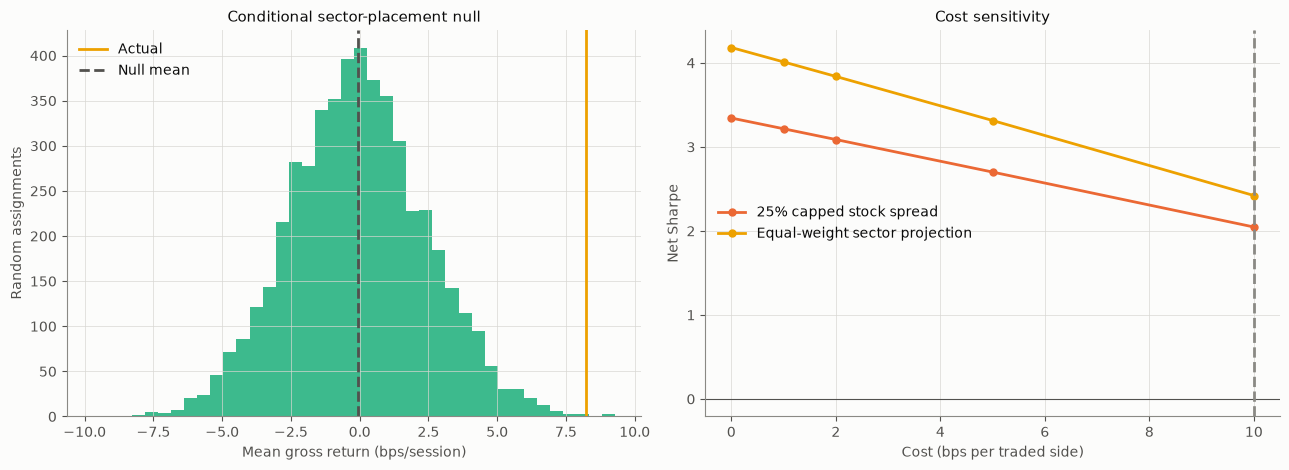

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
axes[0].hist(random_means * 10_000, bins=40, color=CATEGORICAL[2], alpha=0.85)
axes[0].axvline(
    actual_gross_mean * 10_000,
    color=colours["between_sector"],
    linewidth=2.0,
    label="Actual",
)
axes[0].axvline(float(randomisation.loc[0, "null_mean"]) * 10_000, color=INK["reference"], linestyle="--", label="Null mean")
axes[0].set_xlabel("Mean gross return (bps/session)")
axes[0].set_ylabel("Random assignments")
axes[0].set_title("Conditional sector-placement null")
axes[0].legend(loc="upper left")
for arm in ARMS:
    line = cost_curve.loc[cost_curve["arm"].eq(arm)]
    axes[1].plot(
        line["cost_bps_per_side"],
        line["sharpe_net"],
        marker="o",
        color=colours[arm],
        label=labels[arm],
    )
axes[1].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].axvline(COST_BPS, color=INK["muted"], linestyle="--")
axes[1].set_xlabel("Cost (bps per traded side)")
axes[1].set_ylabel("Net Sharpe")
axes[1].set_title("Cost sensitivity")
axes[1].legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "randomisation_and_costs.png", dpi=170, bbox_inches="tight")
plt.show()

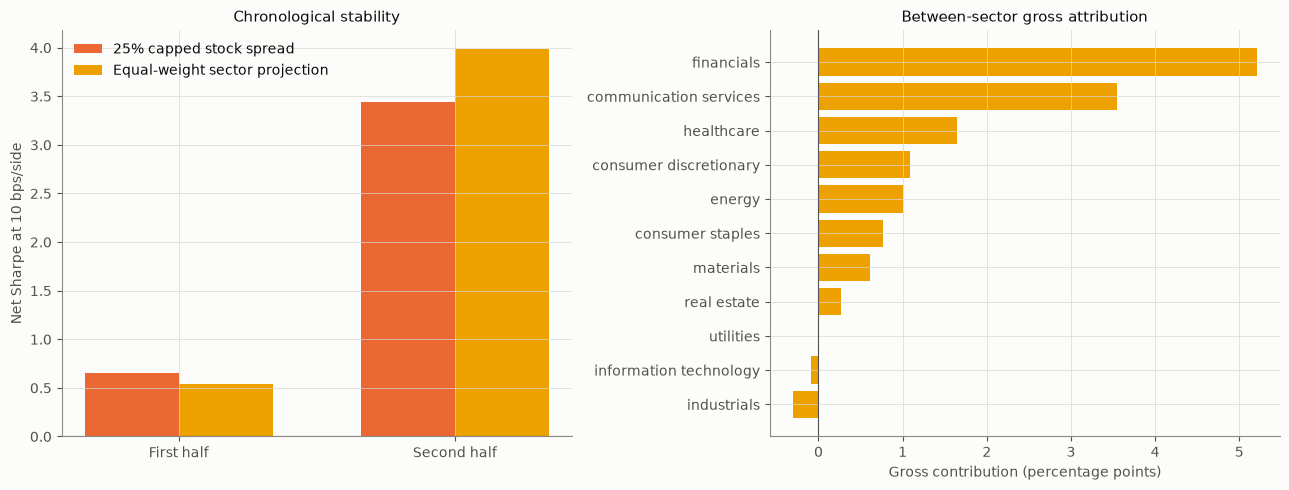

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.0))
half_plot = temporal.pivot(index="period", columns="arm", values="sharpe_net").reindex(
    ["first_half", "second_half"]
)
x = np.arange(len(half_plot))
width = 0.34
for offset, arm in enumerate(ARMS):
    axes[0].bar(
        x + (offset - 0.5) * width,
        half_plot[arm],
        width,
        color=colours[arm],
        label=labels[arm],
    )
axes[0].axhline(0.0, color=INK["reference"], linewidth=0.8)
axes[0].set_xticks(x, ["First half", "Second half"])
axes[0].set_ylabel("Net Sharpe at 10 bps/side")
axes[0].set_title("Chronological stability")
axes[0].legend(loc="best")
sector_plot = sector_attribution.sort_values("projected_gross_contribution")
y = np.arange(len(sector_plot))
axes[1].barh(
    y,
    sector_plot["projected_gross_contribution"] * 100,
    color=colours["between_sector"],
)
axes[1].set_yticks(y, sector_plot["sector"].str.replace("_", " "))
axes[1].axvline(0.0, color=INK["reference"], linewidth=0.8)
axes[1].set_xlabel("Gross contribution (percentage points)")
axes[1].set_title("Between-sector gross attribution")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "temporal_and_sector_attribution.png", dpi=170, bbox_inches="tight")
plt.show()

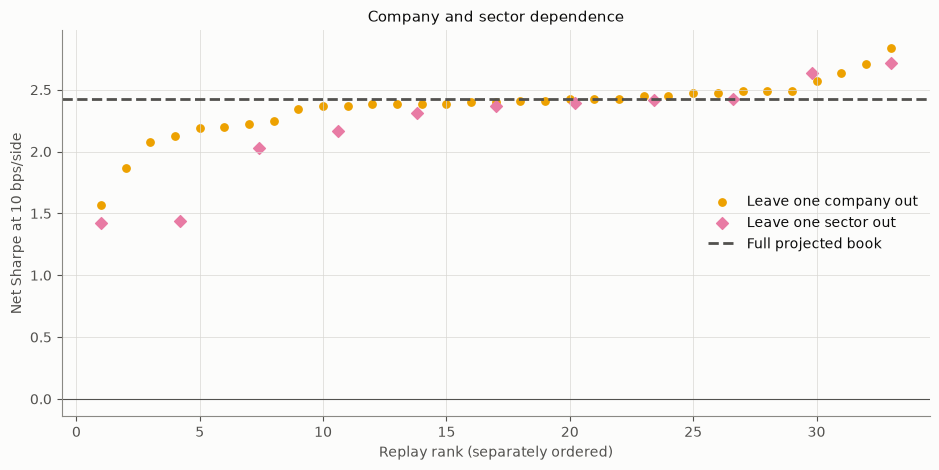

In [13]:
fig, ax = plt.subplots(figsize=(9.5, 4.8))
ax.scatter(
    np.arange(1, len(leave_one_company) + 1),
    leave_one_company["sharpe_net"],
    color=colours["between_sector"],
    s=28,
    label="Leave one company out",
)
ax.scatter(
    np.linspace(1, len(leave_one_company), len(leave_one_sector)),
    leave_one_sector["sharpe_net"],
    color=CATEGORICAL[4],
    marker="D",
    s=36,
    label="Leave one sector out",
)
ax.axhline(float(projected["sharpe_net"]), color=INK["reference"], linestyle="--", label="Full projected book")
ax.axhline(0.0, color=INK["reference"], linewidth=0.8)
ax.set_xlabel("Replay rank (separately ordered)")
ax.set_ylabel("Net Sharpe at 10 bps/side")
ax.set_title("Company and sector dependence")
ax.legend(loc="best")
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "leave_one_out.png", dpi=170, bbox_inches="tight")
plt.show()

## Persist aggregate outputs and decision

In [14]:
coverage.to_csv(OUTPUT_DIR / "coverage.csv", index=False)
addition_feasibility.to_csv(OUTPUT_DIR / "addition11_signal_feasibility.csv", index=False)
construction_audit.to_csv(OUTPUT_DIR / "construction_audit.csv", index=False)
capped_audit.to_csv(OUTPUT_DIR / "capped_target_audit.csv", index=False)
projected_audit.to_csv(OUTPUT_DIR / "projected_target_audit.csv", index=False)
universe_comparison.to_csv(OUTPUT_DIR / "universe_comparison.csv", index=False)
results.to_csv(OUTPUT_DIR / "results.csv", index=False)
paired_inference.to_csv(OUTPUT_DIR / "paired_inference.csv", index=False)
rule_vs_cash.to_csv(OUTPUT_DIR / "rule_vs_cash.csv", index=False)
randomisation.to_csv(OUTPUT_DIR / "randomisation.csv", index=False)
cost_curve.to_csv(OUTPUT_DIR / "cost_curve.csv", index=False)
temporal.to_csv(OUTPUT_DIR / "temporal_results.csv", index=False)
factor_exposure.to_csv(OUTPUT_DIR / "factor_exposure.csv", index=False)
company_attribution.to_csv(OUTPUT_DIR / "company_attribution.csv", index=False)
sector_attribution.to_csv(OUTPUT_DIR / "sector_attribution.csv", index=False)
leave_one_company.to_csv(OUTPUT_DIR / "leave_one_company_out.csv", index=False)
leave_one_sector.to_csv(OUTPUT_DIR / "leave_one_sector_out.csv", index=False)
dependence_summary.to_csv(OUTPUT_DIR / "dependence_summary.csv", index=False)
gates.to_csv(OUTPUT_DIR / "gates.csv", index=False)
for arm in ARMS:
    daily_paths[arm].to_parquet(OUTPUT_DIR / f"{arm}_daily.parquet", index=False)
    ledger_paths[arm].to_parquet(OUTPUT_DIR / f"{arm}_ledger.parquet", index=False)

try:
    git_commit = subprocess.run(
        ["git", "rev-parse", "HEAD"],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    ).stdout.strip()
except (OSError, subprocess.CalledProcessError):
    git_commit = None

manifest = {
    "status": "RETROSPECTIVE_OPENED_WINDOW_IMMUTABLE_UNIVERSE_ROBUSTNESS",
    "notebook": "33_lseg_gemma_original33_universe_robustness.ipynb",
    "git_commit_at_execution": git_commit,
    "seed": SEED,
    "input": {
        "gemma_aggregate_panel": str(GEMMA_PATH.relative_to(REPO_ROOT)),
        "notebook30_manifest": str(NOTEBOOK30_MANIFEST.relative_to(REPO_ROOT)),
        "notebook32_manifest": str(NOTEBOOK32_MANIFEST.relative_to(REPO_ROOT)),
        "price_paths": [str(path.relative_to(REPO_ROOT)) for path in PRICE_PATHS],
        "licensed_headline_text_loaded": False,
    },
    "coverage": json.loads(coverage.to_json(orient="records", date_format="iso"))[0],
    "universe_partition": {
        "original33": list(original_symbols),
        "breadth_additions11": list(addition_symbols),
        "membership_rule": "first three versus fourth frozen member in each sector",
        "membership_frozen_before_return_replay": True,
    },
    "addition11_signal_feasibility": json.loads(
        addition_feasibility.to_json(orient="records")
    )[0],
    "specification": {
        "signal": "unchanged Gemma strongest_event exact +1/-1",
        "rules": [
            "Notebook 30 capacity-capped exact-extrema spread",
            "Notebook 32 equal-weight between-sector projection",
        ],
        "sector_map": "immutable original 11 sectors x 3 companies",
        "projection": "replace every target by its equal-weight sector mean",
        "single_name_cap_input": BASE_SINGLE_NAME_CAP,
        "projected_structural_name_bound": PROJECTED_NAME_BOUND,
        "gross_limit": GROSS_EXPOSURE,
        "scale_up_allowed": False,
        "holding_intervals": 1,
        "cost_bps_per_traded_side": COST_BPS,
        "drifted_weights_marked_against_after_cost_nav": True,
        "final_liquidation": True,
    },
    "construction_audit": json.loads(construction_audit.to_json(orient="records"))[0],
    "universe_comparison": json.loads(universe_comparison.to_json(orient="records")),
    "results": json.loads(results.to_json(orient="records")),
    "paired_inference": json.loads(paired_inference.to_json(orient="records")),
    "rule_vs_cash": json.loads(rule_vs_cash.to_json(orient="records")),
    "randomisation": json.loads(randomisation.to_json(orient="records"))[0],
    "temporal": json.loads(temporal.to_json(orient="records")),
    "factor_exposure": json.loads(factor_exposure.to_json(orient="records")),
    "dependence": json.loads(dependence_summary.to_json(orient="records"))[0],
    "gates": json.loads(gates.to_json(orient="records"))[0],
    "limitations": [
        "the result uses the same opened eight-month window as Notebooks 30-32",
        "immutable-universe robustness is not independent time validation",
        "the sector membership, exact signal, 25% cap, and projection were frozen upstream",
        "the earlier immutable 33-stock contrarian-rank null remains valid and used a different rule",
        "the addition-only cohort has one company per sector, so its sector projection is undefined",
        "projection creates sector-basket positions in zero-signal peers",
        "sector baskets are dollar allocations, not traded sector ETFs",
        "human validation of full-corpus Gemma sentiment remains open",
        "no result is promoted before Gate F1",
    ],
}
(OUTPUT_DIR / "manifest.json").write_text(json.dumps(manifest, indent=2) + "\n")
print(json.dumps(manifest, indent=2))

{
  "status": "RETROSPECTIVE_OPENED_WINDOW_IMMUTABLE_UNIVERSE_ROBUSTNESS",
  "notebook": "33_lseg_gemma_original33_universe_robustness.ipynb",
  "git_commit_at_execution": "8736eebdbb254c8bc6416a09a352f6b5e2f6b1b3",
  "seed": 20260808,
  "input": {
    "gemma_aggregate_panel": "final_experiments/outputs/13_lseg_44_gemma_robustness/gemma4_26b_firm_open_aggregators.parquet",
    "notebook30_manifest": "final_experiments/outputs/30_lseg_gemma_capped_extrema_spread/manifest.json",
    "notebook32_manifest": "final_experiments/outputs/32_lseg_gemma_between_sector_extrema/manifest.json",
    "price_paths": [
      "Data/derived/prices/lseg_us_sector_33_8m.csv"
    ],
    "licensed_headline_text_loaded": false
  },
  "coverage": {
    "firm_open_rows": 5511,
    "sessions": 167,
    "companies": 33,
    "sectors": 11,
    "members_per_sector": 3,
    "excluded_breadth_additions": 11,
    "first_entry_session": "2025-10-27T00:00:00.000",
    "last_entry_session": "2026-06-26T00:00:00.000",
   

## Decision

Both frozen rules pass their **original-33 universe-quality gates**. The
capped stock rule is active on **70/167 sessions** and delivers gross/net
Sharpe **3.344/2.046**, **+10.42%** net return, **-3.42%** maximum drawdown,
and **25.37 bps/side** break-even cost at the frozen 10 bps/side charge. The
between-sector rule is active on **68/167 sessions** and delivers gross/net
Sharpe **4.183/2.421**, **+8.07%** net return, **-2.66%** drawdown, and
**23.25 bps/side** break-even. Both chronological halves are positive after
costs: capped net Sharpes are **0.649/3.438** and projected Sharpes are
**0.543/3.983**.

Removing the 11 breadth additions does not weaken the result descriptively.
Relative to the expanded 44-company runs, capped net Sharpe rises by **0.349**
and projected net Sharpe by **0.553**; turnover falls by 5.77 and 4.92
percentage points per session, respectively. These are same-window universe
comparisons, not independent estimates. The addition-only signal is active
on just **3/167 sessions**, far below the 60-session floor, and its
single-member sectors make the projection infeasible. The evidence therefore
does not depend on those additions and cannot be attributed to an alternative
viable add-11 strategy.

The sector-placement mechanism also replicates: actual projected gross mean
is **8.239 bps/session**, versus a conditional random-assignment null mean of
-0.051 bps and 95% interval **[-4.819, +4.914] bps** (one-sided p =
**0.0010**). All 33 company leave-one-out and all 11 sector leave-one-out
replays remain profitable; minimum net Sharpes are **1.566** and **1.421**.
Financials are still the largest contributor, at **35.8%** of absolute
projected gross contribution, but no one company or sector is necessary.

Neither rule passes the multiplicity-controlled **alpha gate**. Capped mean
net return versus cash is **+6.049 bps/session**, with 95% interval
**[-0.492, +12.415]** and p = **0.0670**. Projected mean is **+4.695
bps/session**, with nominally positive interval **[+0.177, +8.848]** and p =
**0.0346**, but it does not survive BH correction across the two predeclared
rules. Projected-minus-capped return is **-1.353 bps/session** (95% interval
**[-5.768, +3.477]**, p = **0.571**), so the projected rule's higher Sharpe
again comes from lower volatility, not demonstrated return improvement.

This is useful robustness evidence: the Gemma/LSEG result survives an
immutable 25% universe reduction, improves on concentration and turnover,
and now has positive early and late halves. It remains an opened-window,
retrospective strategy result rather than validated alpha. Preserve the
historical 33-stock contrarian-rank null because that was a different signal
and rule; do not blend or retune the frozen candidates on this window.